In [1]:
import rasterio
from rasterio.warp import reproject, calculate_default_transform, Resampling
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import os
import rasterio
from rasterio.enums import Resampling
from shapely.geometry import box

In [2]:
# Load Pre-Event (WV03) & Post-Event (GE01)
Base = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/'
pre = '20231130/'
post = '20240511/'
clip_shp = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/Rectangle.geojson'

## Clip and Reproject to a new CRS (Multispectral (MS) / Panchromatic (PAN) Image)

In [2]:
# def process_image(image_path, output_path, dst_crs="EPSG:32737", target_shape=None, target_transform=None, clip_shp_path=None):
def process_image(image_path, output_path, dst_crs="EPSG:32737", clip_shp_path=None):
    """
    Reproject, resample, and clip an image (MS or PAN).
    
    Args:
        image_path (str): Path to the input image.
        output_path (str): Path to save the processed image.
        dst_crs (str): Coordinate reference system to reproject to (default: EPSG:32737).
        # target_shape (tuple): Shape (height, width) to resample the image. None if no resampling.
        target_transform (Affine): Transformation of the target image (needed for resampling).
        clip_shp_path (str): Path to the shapefile for clipping.
        
    Returns:
        tuple: (Processed image as numpy array, Raster profile)
    """

    # Open the source image
    with rasterio.open(image_path) as src:
        print(f"\n📂 Processing: {image_path}")
        print(f"Original Shape: {src.shape}, Bands: {src.count}")

        # Get band count dynamically
        band_count = src.count

        # ----------------- 1. Reprojection -----------------
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        
        dst_profile = src.profile.copy()
        dst_profile.update({"crs": dst_crs, "transform": transform, "width": width, "height": height})
        
        reprojected = np.zeros((band_count, height, width), dtype=src.dtypes[0])
        
        for i in range(band_count):
            reproject(
                source=src.read(i + 1),
                destination=reprojected[i],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear
            )

        print(f"✅ Reprojected to {dst_crs} - Shape: {reprojected.shape}")

        # ----------------- 2. Clipping -----------------
        if clip_shp_path:
            clip_boundary = gpd.read_file(clip_shp_path)
            clip_geom = [geom for geom in clip_boundary.geometry]
            with rasterio.open(image_path) as src_clip:
                clipped, clipped_transform = mask(src_clip, clip_geom, crop=True)
            reprojected = clipped
            transform = clipped_transform
            dst_profile.update({"height": clipped.shape[1], "width": clipped.shape[2], "transform": transform})
            print(f"✅ Clipped - Shape: {reprojected.shape}")

        # ----------------- 3. Save Output -----------------
        dst_profile.update({"height": reprojected.shape[1], "width": reprojected.shape[2], "count": band_count})
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        with rasterio.open(output_path, 'w', **dst_profile) as dst:
            dst.write(reprojected)
        print(f"💾 Saved: {output_path}")

    return reprojected, dst_profile


In [4]:
ms_pre, ms_pre_profile = process_image(
    image_path = Base + pre + "MS_merged.tif",
    output_path = Base + pre + "MS_pre_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS_merged.tif
Original Shape: (19568, 10795), Bands: 8
✅ Reprojected to EPSG:32737 - Shape: (8, 19568, 10795)
✅ Clipped - Shape: (8, 13975, 10610)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS_pre_processed.tif


In [5]:
pan_pre, pan_pre_profile = process_image(
    image_path = Base + pre + "Pan_merged.tif",
    output_path = Base + pre + "Pan_pre_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/Pan_merged.tif
Original Shape: (78272, 43182), Bands: 1
✅ Reprojected to EPSG:32737 - Shape: (1, 78272, 43182)
✅ Clipped - Shape: (1, 55895, 42436)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/Pan_pre_processed.tif


In [6]:
ms_post, ms_post_profile = process_image(
    image_path = Base + post + "MS_merged.tif",
    output_path = Base + post + "MS_post_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_merged.tif
Original Shape: (11484, 11811), Bands: 4
✅ Reprojected to EPSG:32737 - Shape: (4, 11484, 11811)
✅ Clipped - Shape: (4, 7511, 5702)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_post_processed.tif


In [8]:
pan_post, pan_post_profile = process_image(
    image_path = Base + post + "Pan_merged.tif",
    output_path = Base + post + "Pan_post_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/Pan_merged.tif
Original Shape: (45918, 47220), Bands: 1
✅ Reprojected to EPSG:32737 - Shape: (1, 45918, 47220)
✅ Clipped - Shape: (1, 30025, 22795)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/Pan_post_processed.tif


## Resample Post Multispectral (MS) / Panchromatic (PAN) Image

In [17]:
# # Resampled but doesn't overlap with the pixcel

# import rasterio
# from rasterio.enums import Resampling
# from rasterio.warp import calculate_default_transform, reproject

# # Paths to your source and target raster files
# low_res_path = Base + post + "MS_post_processed.tif"
# high_res_path = Base + pre + "MS_pre_processed.tif"
# output_path = Base + post + "MS_post_processed_resample.tif"

# # Open the high-resolution raster to get its parameters
# with rasterio.open(high_res_path) as high_res_dataset:
#     high_res_transform = high_res_dataset.transform
#     high_res_crs = high_res_dataset.crs
#     high_res_width = high_res_dataset.width
#     high_res_height = high_res_dataset.height
#     high_res_resolution = high_res_dataset.res

# # Open the low-resolution raster to resample
# with rasterio.open(low_res_path) as low_res_dataset:
#     # Calculate the transform and dimensions for the resampled raster
#     transform, width, height = calculate_default_transform(
#         low_res_dataset.crs, high_res_crs, low_res_dataset.width, low_res_dataset.height, *low_res_dataset.bounds,
#         dst_width=high_res_width, dst_height=high_res_height
#     )

#     # Update the metadata for the resampled raster
#     resampled_meta = low_res_dataset.meta.copy()
#     resampled_meta.update({
#         'crs': high_res_crs,
#         'transform': transform,
#         'width': width,
#         'height': height
#     })

#     # Perform the resampling
#     with rasterio.open(output_path, 'w', **resampled_meta) as resampled_dataset:
#         for i in range(1, low_res_dataset.count + 1):
#             reproject(
#                 source=rasterio.band(low_res_dataset, i),
#                 destination=rasterio.band(resampled_dataset, i),
#                 src_transform=low_res_dataset.transform,
#                 src_crs=low_res_dataset.crs,
#                 dst_transform=transform,
#                 dst_crs=high_res_crs,
#                 resampling=Resampling.bilinear
#             )

# print(f"Resampled raster saved to {output_path}")


Resampled raster saved to /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_post_processed_resample.tif


In [4]:
# 不知道这个代码干嘛了
# Clip to intersection ？

import rasterio
from rasterio.enums import Resampling
from shapely.geometry import box

# Paths
high_res_path = Base + pre + "Pan_pre_processed.tif"
low_res_path = Base + post + "Pan_post_processed.tif"
output_high_path = Base + pre + "Pan_pre_processed_croped.tif"
output_low_path = Base + post + "Pan_post_processed_croped.tif"

# Open both rasters
with rasterio.open(high_res_path) as high_res_dataset, rasterio.open(low_res_path) as low_res_dataset:
    # Check if both rasters have non-zero bounds
    if high_res_dataset.bounds and low_res_dataset.bounds:
        # Get bounds of both rasters
        high_bounds = box(*high_res_dataset.bounds)
        low_bounds = box(*low_res_dataset.bounds)

        # Calculate intersection bounds
        intersect_bounds = high_bounds.intersection(low_bounds)
        
        # Handle the case when there is no intersection
        if intersect_bounds.is_empty:
            raise ValueError("❗ No intersection found between the two rasters. Please check your input files.")
        
        intersect_bounds = intersect_bounds.bounds

        # Clip high-resolution raster
        high_window = rasterio.windows.from_bounds(*intersect_bounds, high_res_dataset.transform)
        high_res_clipped = high_res_dataset.read(window=high_window)
        high_res_profile = high_res_dataset.profile
        high_res_profile.update({
            'width': high_window.width,
            'height': high_window.height,
            'transform': high_res_dataset.window_transform(high_window)
        })

        # Save clipped high-resolution raster
        with rasterio.open(output_high_path, 'w', **high_res_profile) as dst:
            dst.write(high_res_clipped)

        # Clip low-resolution raster
        low_window = rasterio.windows.from_bounds(*intersect_bounds, low_res_dataset.transform)
        low_res_clipped = low_res_dataset.read(window=low_window)
        low_res_profile = low_res_dataset.profile
        low_res_profile.update({
            'width': low_window.width,
            'height': low_window.height,
            'transform': low_res_dataset.window_transform(low_window)
        })

        # Save clipped low-resolution raster
        with rasterio.open(output_low_path, 'w', **low_res_profile) as dst:
            dst.write(low_res_clipped)

        print("✅ Both rasters have been clipped to their intersection and saved.")
    else:
        raise ValueError("❗ One or both rasters have zero bounds. Please check your input files.")


/opt/miniconda3/envs/Try/lib/python3.10/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


✅ Both rasters have been clipped to their intersection and saved.


In [5]:
# Resample post to pre

from rasterio.warp import reproject

output_resampled_path = Base + post + "Pan_post_processed_resample.tif"

with rasterio.open(output_high_path) as high_res_dataset, rasterio.open(output_low_path) as low_res_dataset:
    transform = high_res_dataset.transform
    width = high_res_dataset.width
    height = high_res_dataset.height
    crs = high_res_dataset.crs

    # Update metadata for the resampled raster
    resampled_meta = low_res_dataset.meta.copy()
    resampled_meta.update({
        'transform': transform,
        'width': width,
        'height': height,
        'crs': crs
    })

    # Perform resampling
    with rasterio.open(output_resampled_path, 'w', **resampled_meta) as dst:
        for i in range(1, low_res_dataset.count + 1):
            reproject(
                source=rasterio.band(low_res_dataset, i),
                destination=rasterio.band(dst, i),
                src_transform=low_res_dataset.transform,
                src_crs=low_res_dataset.crs,
                dst_transform=transform,
                dst_crs=crs,
                resampling=Resampling.bilinear
            )

print("✅ Low-resolution raster has been resampled and saved.")


✅ Low-resolution raster has been resampled and saved.


## Compute NDWI & ΔNDWI

In [38]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def load_image(filepath):
    """Load a multispectral image using Rasterio."""
    with rasterio.open(filepath) as src:
        image = src.read()  # Read all bands
        profile = src.profile
    return image, profile

# File Paths
ms_pre_path = Base + pre + "MS_pre_processed_croped.tif"
ms_post_path = Base + post + "MS_post_processed_resample.tif"

# Load Images
ms_pre, ms_pre_profile = load_image(ms_pre_path)
ms_post, ms_post_profile = load_image(ms_post_path)

print(f"Pre-Event Image Shape: {ms_pre.shape}")
print(f"Post-Event Image Shape: {ms_post.shape}")

Pre-Event Image Shape: (8, 13975, 10609)
Post-Event Image Shape: (4, 13975, 10609)


In [39]:
def compute_ndwi(green, nir=None):
    """Compute NDWI using Green and NIR, or just Green if NIR is unavailable."""
    if nir is not None:
        return (green - nir) / (green + nir + 1e-6)  # Avoid division by zero
    else:
        return green / 65535.0  # Normalize green reflectance than 255

def mask_zero_values(array):
    """Replace zero values with NaN to avoid affecting NDWI calculations."""
    array = np.where(array == 0, np.nan, array)  # Convert 0 to NaN
    return array

In [41]:
# Extract Green and NIR Bands
green_pre = ms_pre[1]  # Green Band (Index 1, zero-based indexing)
nir_pre = ms_pre[7]    # NIR Band (Index 7 for WV03 multispectral)

green_post = ms_post[1]  # Green Band (Index 1 for GE01, no NIR available)

# Mask Zero Values
green_pre = mask_zero_values(green_pre)
nir_pre = mask_zero_values(nir_pre)
# green_post = mask_zero_values(green_post)

print(f"Green Pre Shape: {green_pre.shape}, NIR Pre Shape: {nir_pre.shape}")
print(f"Green Post Shape: {green_post.shape}")

Green Pre Shape: (13975, 10609), NIR Pre Shape: (13975, 10609)
Green Post Shape: (13975, 10609)


In [42]:
# Calculate NDWI
ndwi_pre = compute_ndwi(green_pre, nir_pre)   # Using Green and NIR for WV03
ndwi_post = compute_ndwi(green_post)          # Using only Green for GE01

# Calculate ΔNDWI (Post - Pre)
delta_ndwi = ndwi_post - ndwi_pre

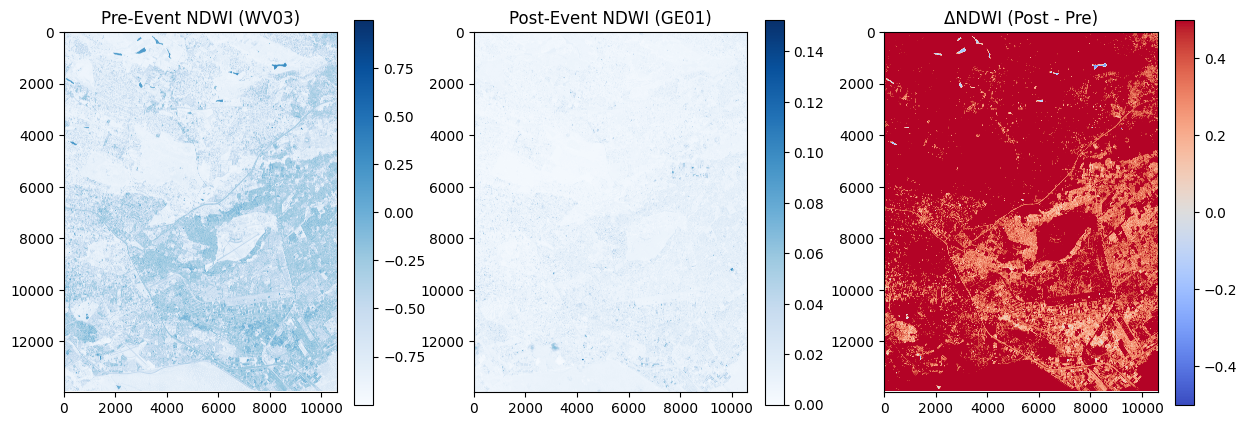

In [43]:
# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ndwi_pre, cmap='Blues')
plt.title("Pre-Event NDWI (WV03)")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(ndwi_post, cmap='Blues')
plt.title("Post-Event NDWI (GE01)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(delta_ndwi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.title("ΔNDWI (Post - Pre)")
plt.colorbar()

plt.show()

In [44]:
def save_geotiff(array, profile, output_path):
    """Save a single-band array as a GeoTIFF."""
    profile.update({
        "count": 1,
        "dtype": array.dtype,
        "driver": "GTiff"
    })

    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(array, 1)
    print(f"Saved: {output_path}")

# Save Output Files
save_geotiff(ndwi_pre, ms_pre_profile, Base + pre + "pre_NDWI.tif")
save_geotiff(ndwi_post, ms_post_profile, Base + post + "post_NDWI.tif")
save_geotiff(delta_ndwi, ms_pre_profile, "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/delta_ndwi.tif")

Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/pre_NDWI.tif
Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/post_NDWI.tif
Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/delta_ndwi.tif


In [45]:
import numpy as np
import pandas as pd

def get_statistics(array, name="Array"):
    """Calculate and display basic statistics of the NDWI array."""
    array_flat = array.flatten()  # Flatten array to 1D
    array_flat = array_flat[~np.isnan(array_flat)]  # Remove NaNs

    stats = {
        "Name": name,
        "Mean": np.mean(array_flat),
        "Median": np.median(array_flat),
        "Min": np.min(array_flat),
        "Max": np.max(array_flat),
        "Std Dev": np.std(array_flat),
        "Pixel Count": array_flat.size
    }

    return pd.Series(stats)

# Display Statistics
ndwi_pre_stats = get_statistics(ndwi_pre, name="Pre-Event NDWI (WV03)")
ndwi_post_stats = get_statistics(ndwi_post, name="Post-Event NDWI (GE01)")
delta_ndwi_stats = get_statistics(delta_ndwi, name="ΔNDWI (Post - Pre)")

df_stats = pd.DataFrame([ndwi_pre_stats, ndwi_post_stats, delta_ndwi_stats])
# print(df_stats)
df_stats

,Name,Mean,Median,Min,Max,Std Dev,Pixel Count
0,Pre-Event NDWI (WV03),-0.600948,-0.683386,-0.999776,0.999761,0.270551,148225584
1,Post-Event NDWI (GE01),0.010143,0.008225,0.000000,0.152590,0.008213,148260775
2,ΔNDWI (Post - Pre),0.611093,0.692418,-0.998434,1.150590,0.267084,148225584


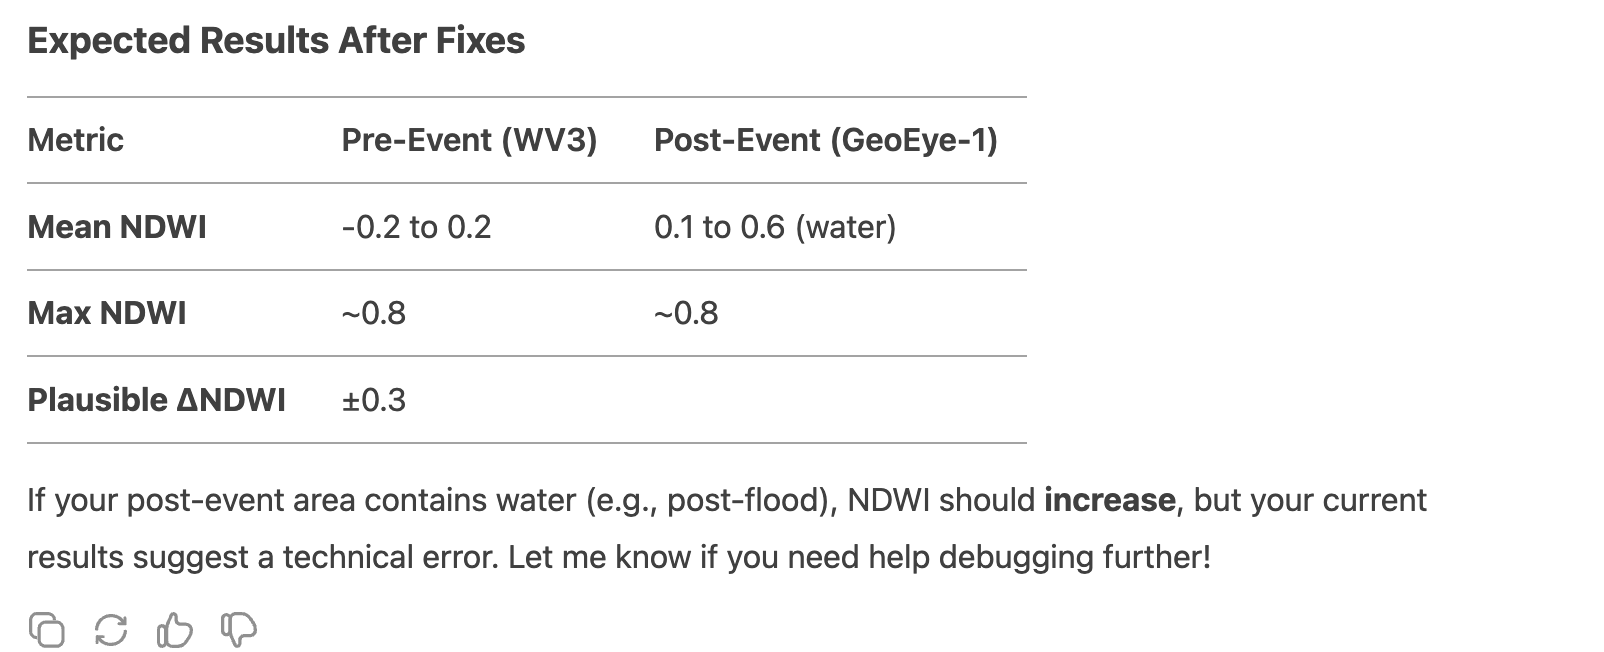

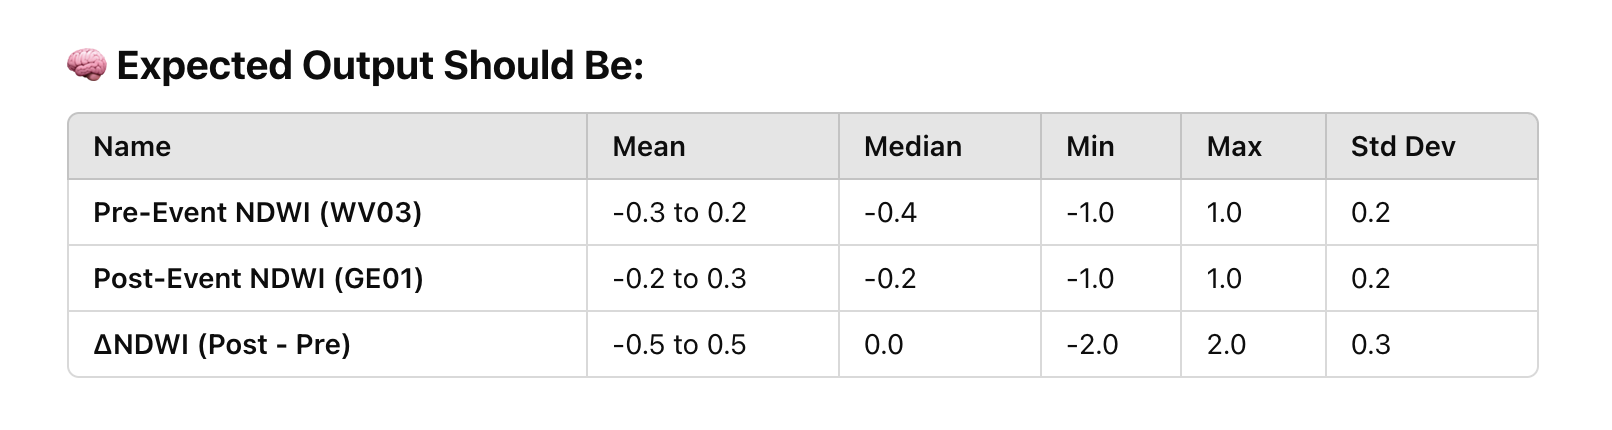